In [1]:
import torch
import pickle
import numpy as np

In [2]:
with open(r"C:\Users\Neela\Documents\GitHub\EntityAspectLinking\picklefiles\final_eal_random.pkl", 'rb') as eal:
    data = pickle.load(eal)

In [3]:
PTH = r"C:\Users\Neela\Documents\GitHub\EntityAspectLinking\picklefiles"

In [4]:
def read_tensor(filename):
    with open(f'{PTH}\\{filename}', 'rb') as f:
        emb = np.load(f, allow_pickle = True)
    return emb

In [5]:
ent_emb = read_tensor('emb_targetentities_random.pkl')

asp_emb = read_tensor('emb_aspectentities_random.pkl')

In [6]:
aspect = [el[1] for el in data]
lngth = [len(el['candidate_aspects']) - 1 for el in aspect]
asp_count = sum([len(el['candidate_aspects']) for el in aspect])

In [23]:
asp_emb.shape
ent_emb.shape

torch.Size([2500, 100])

In [8]:
dataset = np.zeros((asp_count, 201))

In [9]:
i = 0
k = 0
for _ in range(len(dataset)):
    while(k < len(lngth)):
        dataset[i, : ent_emb.shape[1]] = ent_emb[k]
        dataset[i, : ent_emb.shape[1] : -1] = asp_emb[i]
        dataset[i, -1] = 1
        i += 1
        for _ in range(lngth[k]):
            dataset[i, : ent_emb.shape[1]] = ent_emb[k]
            dataset[i, ent_emb.shape[1] : -1] = asp_emb[i]
            dataset[i, -1] = 0
            i += 1
        k += 1

In [10]:
from imblearn.under_sampling import RandomUnderSampler

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
X = dataset[:,:-1]
sc = StandardScaler()
X = sc.fit_transform(X)
y = dataset[:,-1]

In [13]:
undersample = RandomUnderSampler(sampling_strategy='majority')

In [14]:
X, y = undersample.fit_resample(X, y)

In [15]:
from sklearn.manifold import TSNE
tsne = TSNE()
tsne_data = tsne.fit_transform(X)


C:\Users\Neela\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\Neela\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


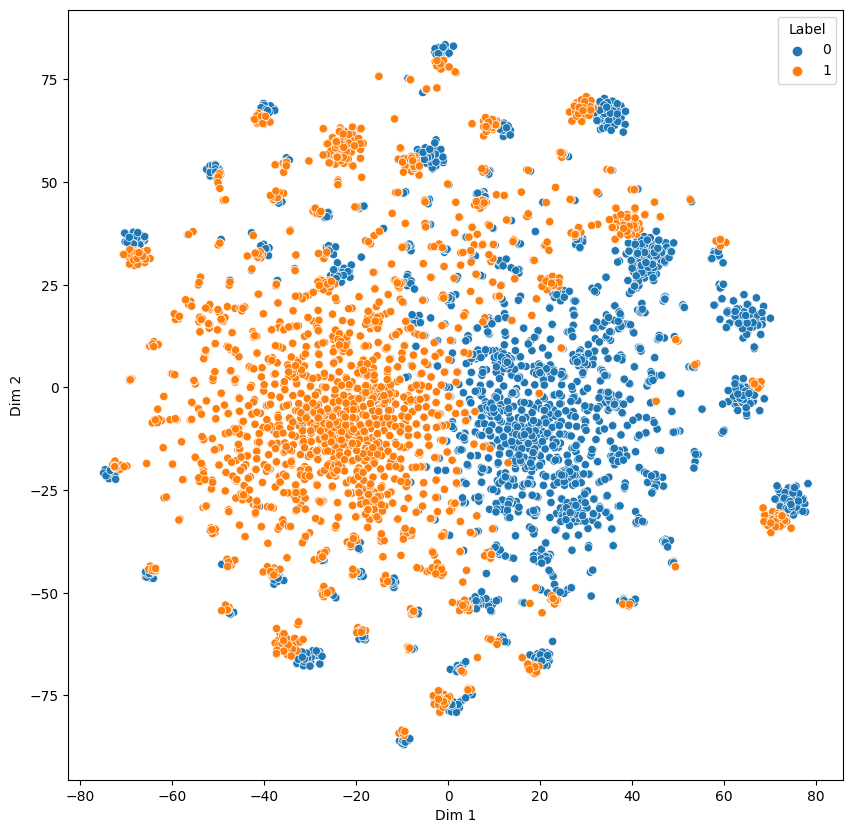

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
dat = np.column_stack((tsne_data, y))
fin_data = pd.DataFrame(dat, columns = ('Dim 1', 'Dim 2', 'Label'))
fin_data['Label'] = fin_data['Label'].astype('int')
plt.figure(figsize = (10, 10))
plot = sns.scatterplot(data = fin_data, x = 'Dim 1', y = 'Dim 2', hue = 'Label')
fig = plot.get_figure()
plt.show()
fig.savefig('tsne.png')

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(tsne_data,y,test_size = 0.3, random_state = 42)

In [18]:
from lazypredict.Supervised import LazyClassifier
clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:03<00:00,  8.13it/s]

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
ExtraTreesClassifier               0.95               0.95     0.95      0.95   
BaggingClassifier                  0.94               0.94     0.94      0.94   
RandomForestClassifier             0.94               0.94     0.94      0.94   
DecisionTreeClassifier             0.93               0.93     0.93      0.93   
XGBClassifier                      0.93               0.93     0.93      0.93   
LGBMClassifier                     0.92               0.92     0.92      0.92   
KNeighborsClassifier               0.92               0.92     0.92      0.92   
ExtraTreeClassifier                0.91               0.91     0.91      0.91   
LabelPropagation                   0.84               0.84     0.84      0.84   
LabelSpreading                     0.83               0.83     0.83      0.83   
AdaBoostClassifier          

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state = 42)

In [20]:
y_test.shape

(1500,)

In [21]:
models,predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)

'tuple' object has no attribute '__name__'
Invalid Classifier(s)


100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:12<00:00,  2.39it/s]

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
AdaBoostClassifier                 1.00               1.00     1.00      1.00   
BaggingClassifier                  1.00               1.00     1.00      1.00   
XGBClassifier                      1.00               1.00     1.00      1.00   
SVC                                1.00               1.00     1.00      1.00   
RandomForestClassifier             1.00               1.00     1.00      1.00   
QuadraticDiscriminantAnalysis      1.00               1.00     1.00      1.00   
PassiveAggressiveClassifier        1.00               1.00     1.00      1.00   
LogisticRegression                 1.00               1.00     1.00      1.00   
LinearSVC                          1.00               1.00     1.00      1.00   
LGBMClassifier                     1.00               1.00     1.00      1.00   
DecisionTreeClassifier      

In [22]:
y_pred = svc.predict(X_test)

NameError: name 'svc' is not defined

In [ ]:
y_test.shape
y_pred.shape

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(y_test,y_pred)